In [1]:
from utils import * 

In [2]:
# import cvxpy as cp
# import numpy as np

# n = 5
# points = np.array([(0,1),(0,0),(1,0),(5,5),(4,7)])
# target_area = 10

# theta = np.linspace(0,2*np.pi,n,endpoint=False)
# u = np.vstack((np.cos(theta),np.sin(theta))).T

# # initial support estimate
# h0 = np.max(points @ u.T, axis=0)

# h = cp.Variable(n)

# constraints = []

# # convexity constraints
# for i in range(n):
#     constraints.append(
#         h[(i+1)%n] + h[(i-1)%n] - 2*h[i] >= 0
#     )

# # finite difference derivative
# hp = []
# for i in range(n):
#     hp.append((h[(i+1)%n] - h[(i-1)%n]) / 2)
# hp = cp.hstack(hp)

# area_expr = 0.5*(cp.sum_squares(h) - cp.sum_squares(hp))

# constraints.append(area_expr >= target_area)

# objective = cp.Minimize(cp.sum_squares(h - h0))

# prob = cp.Problem(objective,constraints)
# prob.solve()

# print("Support values:",h.value)

## 4. Convex optimization for maximizing polygon area

A classic convex result:

If the vertices must lie in a convex region, maximizing the polygon area with fixed ordering can be solved via convex optimization or linear programming variants.

Example:

Maximize

$\sum{x_{i}y_{i+1}−x_{i+1}y_{i}}$

subject to linear constraints defining the region.

[(np.float64(0.0), np.float64(0.9743589743589746)), (np.float64(0.0), np.float64(0.7564102564102563)), (np.float64(1.0), np.float64(-1.2179487179487178)), (np.float64(5.243589743589744), np.float64(0.2692307692307687)), (np.float64(3.7564102564102564), np.float64(2.2179487179487176))]
Area: 10.0
[[0 0]
 [0 1]
 [1 0]
 [5 1]
 [4 1]]
[[ 0.          0.97435897]
 [ 0.          0.75641026]
 [ 1.         -1.21794872]
 [ 5.24358974  0.26923077]
 [ 3.75641026  2.21794872]]


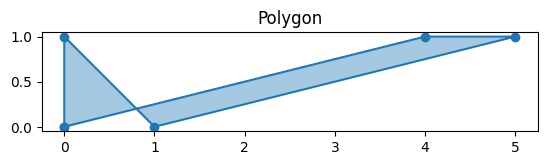

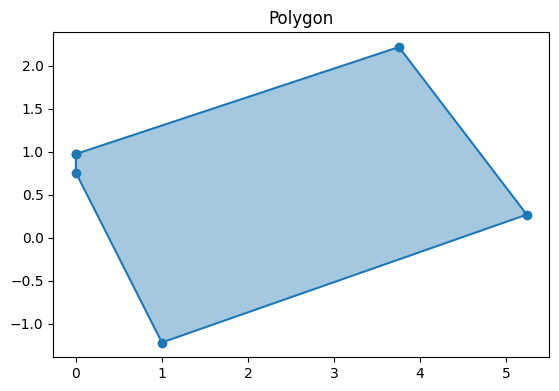

In [3]:
import cvxpy as cp
import numpy as np

points = np.array([(0,0),(0,1),(1,0),(5,1),(4,1)])
# n = len(points)
target_area = 10

# x0 = points[:,0]
# y0 = points[:,1]

# # compute gradient of area
# gx = np.zeros(n)
# gy = np.zeros(n)

# for i in range(n):
#     gx[i] = 0.5*(y0[(i+1)%n] - y0[(i-1)%n])
#     gy[i] = 0.5*(x0[(i-1)%n] - x0[(i+1)%n])

# A0 = 0
# for i in range(n):
#     j=(i+1)%n
#     A0 += x0[i]*y0[j] - x0[j]*y0[i]
# A0 *= 0.5

# x = cp.Variable(n)
# y = cp.Variable(n)

# area_linear = A0 + gx @ (x-x0) + gy @ (y-y0)

# objective = cp.Minimize(
#     cp.sum_squares(x-x0) + cp.sum_squares(y-y0)
# )

# constraints=[area_linear >= target_area]

# prob=cp.Problem(objective,constraints)
# prob.solve()

z_opt, area_opt = maxPolyAreaConvexOptim(points, target_area)

print(list(zip(z_opt[:,0], z_opt[:,1])))
print("Area:", area_opt)
print(points)
print(z_opt)
plot_poly(points)
plot_poly(z_opt)

## 4.2 Convex optimization for maximizing polygon area (linearized (not working))

In [4]:
import cvxpy as cp
import numpy as np

points = np.array([(0,0),(0,1),(1,0),(5,1),(4,1)])
n = len(points)
target_area = 10

x0 = points[:,0]
y  = points[:,1]  # fixed

# LP variable
x = cp.Variable(n)

# --- AREA (linear) ---
area_terms = []
for i in range(n):
    j = (i+1) % n
    area_terms.append(x[i]*y[j] - x[j]*y[i])

area = 0.5 * cp.sum(area_terms)

# --- CONVEXITY constraints ---
conv_constraints = []

for i in range(n):
    i1 = i
    i2 = (i+1) % n
    i3 = (i+2) % n

    expr = (
        (x[i2]-x[i1])*(y[i3]-y[i2])
        - (x[i3]-x[i2])*(y[i2]-y[i1])
    )

    conv_constraints.append(expr >= 0)

# --- LP objective ---
objective = cp.Minimize(cp.sum(x))

constraints = [
    area >= target_area
] + conv_constraints

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.HIGHS)

print("status:", prob.status)

if prob.status == "optimal":
    x_opt = np.array(x.value).reshape(-1)
    new_points = np.column_stack((x_opt, y))

    print("New points:", new_points)
    print("Area:", area.value)
else:
    print("No feasible solution found.")

status: unbounded
No feasible solution found.


## 5. Convex relaxation approaches

If you really want to move vertices freely, common strategies are:

**Semidefinite relaxation**

Introduce matrix variables:

$X=\begin{bmatrix} x \\\ y \end{bmatrix}$

Relax bilinear terms using SDP constraints.

This leads to **semidefinite programming**.

Related field:
Semidefinite Programming

[[0 0]
 [0 1]
 [1 0]
 [5 1]
 [4 1]]
[[-5.98886156e-14 -6.54500145e-14]
 [-9.50191109e-14  1.00000000e+00]
 [ 1.00000000e+00  8.29842171e-14]
 [ 5.00000000e+00  1.00000000e+00]
 [ 4.00000000e+00  1.00000000e+00]]
13.4386516185131


/home/kuenem/Documents/development/lectures/Master Thesis/Test/Geometry/utils.py:102: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  [X,cp.reshape(z,(m,1))],
/home/kuenem/Documents/development/lectures/Master Thesis/Test/Geometry/utils.py:103: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  [cp.reshape(z,(1,m)),np.ones((1,1))]


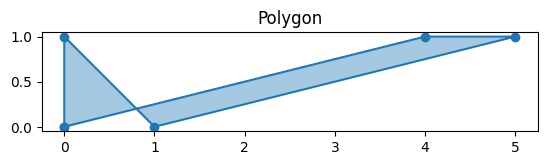

In [5]:
import cvxpy as cp
import numpy as np

points=np.array([(0,0),(0,1),(1,0),(5,1),(4,1)])
target_area=10
# n=len(points)

# z0=points.flatten()
# m=2*n

# z=cp.Variable(m)
# X=cp.Variable((m,m),PSD=True)

# # area matrix
# Q=np.zeros((m,m))

# for i in range(n):
#     j=(i+1)%n
#     xi,yi=2*i,2*i+1
#     xj,yj=2*j,2*j+1

#     Q[xi,yj]+=0.5
#     Q[xj,yi]-=0.5

# area=cp.trace(Q@X)

# # Schur complement
# constraints=[
#     cp.bmat([
#         [X,cp.reshape(z,(m,1))],
#         [cp.reshape(z,(1,m)),np.ones((1,1))]
#     ]) >> 0,
#     area>=target_area
# ]

# objective=cp.Minimize(cp.sum_squares(z-z0))

# prob=cp.Problem(objective,constraints)
# prob.solve()

z_opt, area_opt = maxPolyAreaConvexRelax(points, target_area)

print(points)
print(z_opt)
print(area_opt)
plot_poly(z_opt)

## 6. Practical approach used in geometry optimization

Most implementations use:

Nonlinear optimization
Area constraint
Regularization

Example:

$min∣∣p−p_{0}∣∣^{2}$

subject to

$A(p)=x$

Solved with:

* SQP
* interior point methods

Beginning points: [[0 0]
 [0 1]
 [1 0]
 [0 5]
 [4 1]]
Beginning area: 9.99999912392299
New points: [[-1.08624553  1.23145038]
 [-0.78620869 -0.85961895]
 [ 3.55260327 -0.72975934]
 [ 1.03418751  5.50789003]
 [ 2.28566349  1.85003797]]
Area: 9.99999912392299


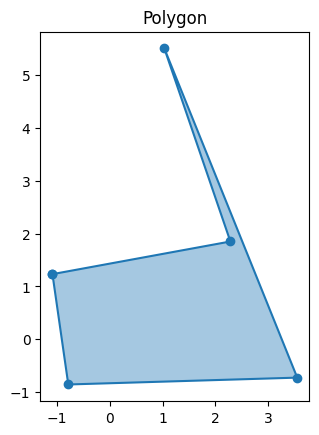

In [6]:
import numpy as np
from scipy.optimize import minimize

points = np.array([(0,0), (0,1), (1,0), (0,5), (4,1)])
# plot_poly(points)
# n = len(points)
target_area = 10

# z0 = points.flatten()

# def polygon_area(z):
#     pts = z.reshape(n,2)
#     area = 0
#     for i in range(n):
#         j = (i+1)%n
#         area += pts[i,0]*pts[j,1] - pts[j,0]*pts[i,1]
#     return 0.5*area

# def objective(z):
#     return np.sum((z - z0)**2)

# def constraint(z):
#     return polygon_area(z) - target_area

# cons = {'type':'eq','fun':constraint}

# res = minimize(objective, z0, constraints=[cons])

z_opt, area_opt = maxPolyAreaGeometricOptim(points, target_area)

# result = res.x.reshape(n,2)
print("Beginning points:", points)
print("Beginning area:", area_opt)
print("New points:", z_opt)
print("Area:", area_opt)
plot_poly(z_opt)


In [7]:
# import pulp
# import numpy as np
# import matplotlib.pyplot as plt

# # ============================================================================
# # 1. Define the problem data
# # ============================================================================
# # A set of candidate vertices
# points = np.array([
#     [0, 0], [1, 0], [2, 0], [2, 1], [2, 2], [1, 2], [0, 2], [0, 1]
# ])
# n = len(points)  # Number of vertices

# # Calculate the Euclidean distance between all pairs of points (for edge costs)
# dist = np.zeros((n, n))
# for i in range(n):
#     for j in range(n):
#         dist[i, j] = np.linalg.norm(points[i] - points[j])

# # Target area (2.0 square units)
# target_area = 2.0

# # ============================================================================
# # 2. Create the MILP model
# # ============================================================================
# model = pulp.LpProblem("Polygon_With_Fixed_Area", pulp.LpMinimize)

# # --- Decision Variables ---
# # x[i, j] = 1 if the directed edge from i to j is used, 0 otherwise
# x = {}
# for i in range(n):
#     for j in range(n):
#         if i != j:
#             x[i, j] = pulp.LpVariable(f"x_{i}_{j}", cat=pulp.LpBinary)

# # --- Objective: Minimize total perimeter ---
# model += pulp.lpSum(dist[i, j] * x[i, j] for i in range(n) for j in range(n) if i != j)

# # --- Constraints ---

# # 1. Each vertex has exactly one incoming and one outgoing edge
# for i in range(n):
#     model += pulp.lpSum(x[i, j] for j in range(n) if j != i) == 1  # Outgoing
#     model += pulp.lpSum(x[j, i] for j in range(n) if j != i) == 1  # Incoming

# # 2. Subtour elimination (prevents multiple disjoint cycles)
# # This is a simplified version; for a robust solution, you'd need
# # a more comprehensive formulation or a lazy constraint callback.
# # This constraint only prohibits cycles of length 2.
# for i in range(n):
#     for j in range(i+1, n):
#         model += x[i, j] + x[j, i] <= 1

# # 3. Area Constraint: Use the triangulation method to enforce the target area.
# # This is a placeholder where the polygon's area is pre-computed as
# # a linear combination of selected triangles' areas.
# # For a polygon defined by the cycle, the area is:
# # area = 1/2 * |sum_{i} (x_i*y_{i+1} - x_{i+1}*y_i)|
# # The absolute value is handled by adding a binary variable (z) to decide orientation.
# # We also use a large constant (M) for the big-M method.
# M = 10000
# z = pulp.LpVariable("z", cat=pulp.LpBinary)

# # Calculate the signed area as a linear expression of the x variables
# signed_area_expr = 0
# for i in range(n):
#     for j in range(n):
#         if i != j:
#             # The contribution of edge (i, j) to the signed area is x_i*y_j - x_j*y_i.
#             # However, since x[i, j] is a binary variable, we need to linearize the product.
#             # We use the fact that the vertices (points) are fixed, so the product is constant.
#             # The actual linear expression for the signed area is:
#             # 1/2 * sum_{i,j} (points[i,0]*points[j,1] - points[j,0]*points[i,1]) * x[i, j]
#             signed_area_expr += (points[i,0]*points[j,1] - points[j,0]*points[i,1]) * x[i, j]
# # The signed area expression is now linear.
# # We enforce the absolute value using the binary variable z.
# # area = z * signed_area + (1-z) * (-signed_area)
# model += (signed_area_expr - target_area) <= M * (1 - z)
# model += (-signed_area_expr - target_area) <= M * z
# model += (target_area - signed_area_expr) <= M * (1 - z)
# model += (target_area + signed_area_expr) <= M * z

# # ============================================================================
# # 3. Solve and display results
# # ============================================================================
# solver = pulp.PULP_CBC_CMD(msg=True)
# model.solve(solver)

# print(f"Status: {pulp.LpStatus[model.status]}")
# # if model.status == pulp.LpOptimal:
# if pulp.LpStatus[model.status] == "Optimal":
#     print(f"Optimal Perimeter: {model.objective.value()}")

#     # Extract the cycle
#     selected_edges = [(i, j) for i in range(n) for j in range(n) if i != j and x[i, j].varValue > 0.5]
#     if selected_edges:
#         # Build the polygon order (simplified)
#         ordered_cycle = [selected_edges[0][0]]
#         current = selected_edges[0][1]
#         ordered_cycle.append(current)
#         for _ in range(len(selected_edges) - 1):
#             for (i, j) in selected_edges:
#                 if i == current and j != ordered_cycle[-2]:
#                     ordered_cycle.append(j)
#                     current = j
#                     break
#         polygon_points = points[ordered_cycle]

#         # Plotting
#         plt.figure(figsize=(8, 8))
#         plt.plot(points[:, 0], points[:, 1], 'bo')
#         for i, (x, y) in enumerate(points):
#             plt.text(x, y, f' {i}', fontsize=12)
#         closed_points = np.vstack([polygon_points, polygon_points[0]])
#         plt.plot(closed_points[:, 0], closed_points[:, 1], 'r-', linewidth=2)
#         plt.fill(closed_points[:, 0], closed_points[:, 1], 'r', alpha=0.3)
#         plt.title(f"Minimum Perimeter Polygon (Area = {target_area})")
#         plt.axis('equal')
#         plt.grid(True)
#         plt.show()
#     else:
#         print("No valid cycle found.")
# else:
#     print("No optimal solution found.")